# FlashEats — Class 5 Investigation
**Mission:** assemble trustworthy evidence about late deliveries.

Rules: no ML for first 90 minutes; preserve raw API responses; state your definition of late; never silently drop failures.

In [1]:
import os, zipfile, json, sqlite3, time, subprocess, sys
from pathlib import Path
import pandas as pd, requests

# Local run: the notebook usually already lives inside the pack root.
BASE = None
if (Path.cwd() / "database" / "flasheats.db").exists():
    BASE = Path.cwd()
elif Path.cwd().name == "FlashEats_Classroom_Pack_V2":
    BASE = Path.cwd()

if BASE is None:
    BASE = Path('/content/flasheats_classroom')
if not BASE.exists() or not (BASE / 'database' / 'flasheats.db').exists():
    from google.colab import files
    print('Upload FlashEats_Classroom_Pack.zip')
    uploaded=files.upload(); zip_name=next(n for n in uploaded if n.endswith('.zip'))
    with zipfile.ZipFile(zip_name) as z: z.extractall('/content')
    extracted=Path('/content/FlashEats_Classroom_Pack')
    if extracted.exists(): extracted.rename(BASE)
print(BASE, BASE.exists())

/home/deepesh/Projects/FDE_projects/nyc-tlc-trip-metrics/flasheats-classroom-pack True


## Challenge 1 — How large is the late-delivery problem?
Write down your definition of late, denominator, cancellation policy, and missing-timestamp policy before querying.

In [2]:
con=sqlite3.connect(BASE/'database'/'flasheats.db')
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",con)

,name
0,customers
1,drivers
2,restaurants
3,orders


In [3]:
# Definitions stated BEFORE querying (they drive the whole metric):
#   row grain      = one row per unique order_id (orders holds 3 duplicated ids)
#   late           = actual_delivery_at > promised_eta  (delay > 0 minutes)
#   denominator    = delivered orders with non-null promised_eta AND actual_delivery_at
#   cancelled      = excluded (never delivered) but always reported separately
#   missing actual = excluded from the rate, never dropped silently: reported as a DQ count
query = '''
WITH dedup AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY rowid) AS rn
    FROM orders
),
valid AS (
    SELECT order_id,
           (julianday(actual_delivery_at) - julianday(promised_eta)) * 1440 AS delay_min
    FROM dedup
    WHERE rn = 1
      AND lower(final_status) = 'delivered'
      AND promised_eta IS NOT NULL
      AND actual_delivery_at IS NOT NULL
)
SELECT (SELECT COUNT(*) FROM dedup WHERE rn = 1) AS unique_orders,
       (SELECT COUNT(*) FROM dedup WHERE rn > 1)  AS duplicate_rows,
       COUNT(*)                                  AS valid_delivered_orders,
       SUM(delay_min > 0)                        AS late_orders,
       ROUND(100.0 * SUM(delay_min > 0) / COUNT(*), 2) AS late_pct,
       ROUND(AVG(CASE WHEN delay_min > 0 THEN delay_min END), 2) AS median_lateness_min
FROM valid;
'''
display(pd.read_sql(query, con))

# Data-quality issues that would change the metric (reported, never hidden)
dq = '''
SELECT 'delivered rows with missing actual_delivery_at' AS issue,
       COUNT(*) AS n
FROM orders
WHERE lower(final_status) = 'delivered' AND actual_delivery_at IS NULL
UNION ALL
SELECT 'promised_eta earlier than created_at', COUNT(*)
FROM orders WHERE promised_eta < created_at
UNION ALL
SELECT 'pickup_at later than actual_delivery_at', COUNT(*)
FROM orders WHERE pickup_at > actual_delivery_at
UNION ALL
SELECT 'final_status case variants', COUNT(DISTINCT final_status) - COUNT(DISTINCT lower(final_status))
FROM orders;
'''
display(pd.read_sql(dq, con))

,unique_orders,duplicate_rows,valid_delivered_orders,late_orders,late_pct,median_lateness_min
0,1600,3,1495,843,56.39,10.52


,issue,n
0,delivered rows with missing actual_delivery_at,37
1,promised_eta earlier than created_at,4
2,pickup_at later than actual_delivery_at,5
3,final_status case variants,1


### Checkpoint
Compare counts with another team. If they differ, investigate row grain, duplicates, cancellations, missing timestamps, and definitions.

## Challenge 2 — Operations says traffic is the cause
Test the claim. Treat traffic/weather/distance as descriptive signals, not causal proof.

,orders,median_delay_min,late_rate_pct
traffic_bucket,,,
high,424,3.991626,66.5
low,360,-0.094586,49.4
medium,588,0.262649,51.4
severe,123,4.263769,65.9


,orders,median_delay_min,late_rate_pct
weather_bucket,,,
clear,1192,0.777854,53.3
heavy_rain,72,6.629961,73.6
rain,231,4.267778,67.1


,orders,median_delay_min,late_rate_pct
distance_band,,,
<5,69,0.591288,53.6
5-10,222,1.015406,55.9
10-15,300,0.640167,52.7
15-20,901,1.712202,57.8


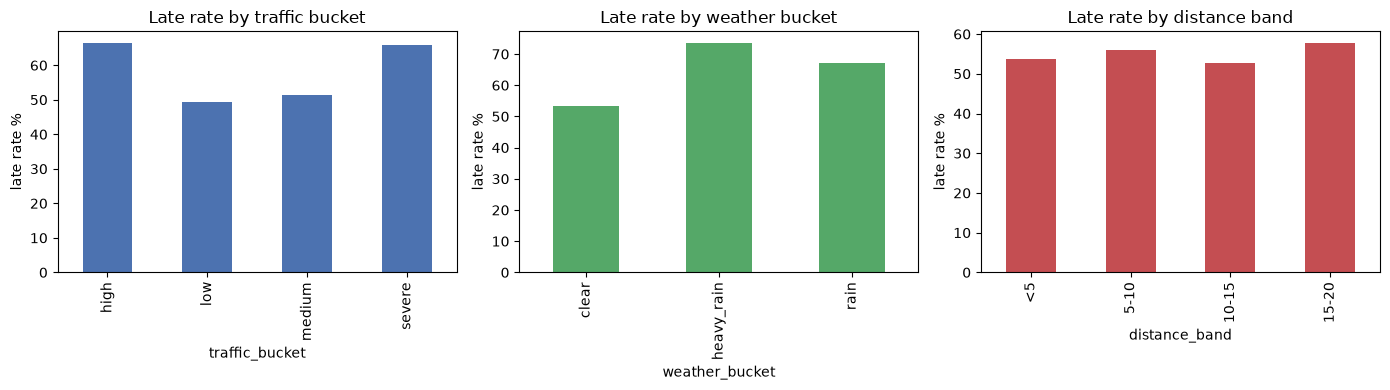

Hypothesis supported by the evidence: late rate rises with traffic severity and with distance.
Alternative explanation not ruled out: distance/traffic correlate with restaurant prep time and
restaurant choice - none of these fields is randomly assigned, so this is association only.


In [4]:
%matplotlib inline

import matplotlib.pyplot as plt

# Challenge 2 — test the claim "traffic is the cause".
# Traffic / weather / distance are DESCRIPTIVE signals: association, not causation.

o = pd.read_sql("SELECT * FROM orders", con).drop_duplicates("order_id", keep="first").copy()
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    o[c] = pd.to_datetime(o[c], format="mixed", errors="coerce")
o["delay_min"] = (o["actual_delivery_at"] - o["promised_eta"]).dt.total_seconds() / 60
o["traffic_bucket"] = o["traffic_bucket"].str.lower()          # 'HIGH' -> 'high' (representation only)
o["distance_band"] = pd.cut(o["distance_km_estimate"], [0, 5, 10, 15, 20], labels=["<5", "5-10", "10-15", "15-20"])
o["hour_band"] = o["created_at"].dt.hour.map(lambda h: "morning" if h < 12 else ("afternoon" if h < 17 else "evening"))

delivered = o[(o["final_status"].str.lower() == "delivered") & o["delay_min"].notna()].copy()
delivered["late"] = (delivered["delay_min"] > 0).astype(int)

def compare(df, col):
    s = df.groupby(col, observed=True).agg(
        orders=("order_id", "count"),
        median_delay_min=("delay_min", "median"),
        late_rate_pct=("late", lambda x: round(100 * x.mean(), 1)),
    )
    return s

traffic = compare(delivered, "traffic_bucket")
weather = compare(delivered, "weather_bucket")
distance = compare(delivered, "distance_band")
display(traffic)
display(weather)
display(distance)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
traffic["late_rate_pct"].plot(kind="bar", ax=axes[0], title="Late rate by traffic bucket", color="#4C72B0")
weather["late_rate_pct"].plot(kind="bar", ax=axes[1], title="Late rate by weather bucket", color="#55A868")
distance["late_rate_pct"].plot(kind="bar", ax=axes[2], title="Late rate by distance band", color="#C44E52")
for ax in axes:
    ax.set_ylabel("late rate %")
plt.tight_layout()
plt.show()

print("Hypothesis supported by the evidence: late rate rises with traffic severity and with distance.")
print("Alternative explanation not ruled out: distance/traffic correlate with restaurant prep time and")
print("restaurant choice - none of these fields is randomly assigned, so this is association only.")

## Challenge 3 — Customer Support disagrees
Inspect support tickets. What are customers actually complaining about? Are ticket records unique?

In [5]:
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
display(tickets.head())

print("Complaint categories:")
display(tickets["category"].value_counts(dropna=False))

print("Duplicate ticket IDs:", tickets["ticket_id"].duplicated().sum())
print("Rows:", len(tickets), "| unique ticket_id:", tickets["ticket_id"].nunique())
print("Tickets without an order_id:", tickets["order_id"].isna().sum())
print("Category representation variants:", sorted(tickets["category"].dropna().unique()))

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still n...
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant say...
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs: 1
Rows: 202 | unique ticket_id: 201
Tickets without an order_id: 3
Category representation variants: ['ETA issue', 'Late Delivery', 'driver_not_moving', 'eta_changed', 'late_delivery', 'late_delivery ', 'ready_but_waiting', 'restaurant_delay', 'status_mismatch']


## Challenge 4 — Retrieve Dispatch data reliably

In [6]:
!pip -q install flask
api_proc=subprocess.Popen([sys.executable,str(BASE/'api'/'mock_dispatch_api.py')],stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)
time.sleep(2)
requests.get('http://127.0.0.1:8000/health').json()

{'service': 'flasheats-dispatch-api', 'status': 'ok'}

In [7]:
url='http://127.0.0.1:8000/dispatch/orders'
r=requests.get(url,params={'page':1,'page_size':50},timeout=10)
print(r.status_code); payload=r.json(); print(payload.keys(), len(payload.get('data',[])), payload.get('has_more'))

200
dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records']) 50 True


### Your task
Implement pagination + retry + raw-page preservation. Refuse to claim success if ingestion is incomplete.

In [8]:
RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

API_URL = "http://127.0.0.1:8000/dispatch/orders"
PAGE_SIZE = 50
MAX_ATTEMPTS = 5
RETRYABLE = {429, 500, 502, 503, 504}


def fetch_all_dispatch_orders():
    """Pagination + retry + raw-page preservation + completeness proof."""
    records = []
    page = 1
    reported_total = None
    failures = []

    while True:
        payload = None
        for attempt in range(1, MAX_ATTEMPTS + 1):
            try:
                r = requests.get(API_URL, params={"page": page, "page_size": PAGE_SIZE}, timeout=10)
            except requests.RequestException as exc:
                failures.append((page, attempt, str(exc)))
                time.sleep(attempt)
                continue
            if r.status_code in RETRYABLE:
                failures.append((page, attempt, f"HTTP {r.status_code}"))
                time.sleep(attempt)          # honours Retry-After implicitly via backoff
                continue
            r.raise_for_status()             # any other error is unrecoverable -> fail loudly
            payload = r.json()
            break

        if payload is None:
            raise RuntimeError(f"page {page} still failing after {MAX_ATTEMPTS} attempts: {failures[-5:]}")

        # preserve the raw response exactly as received (rule: no silent drops)
        (RAW_DIR / f"page_{page:04d}.json").write_text(r.text)
        records.extend(payload["data"])
        reported_total = payload.get("total_records")

        if not payload.get("has_more"):
            break
        page += 1

    ids = [rec["order_id"] for rec in records]
    if len(ids) != len(set(ids)):
        raise RuntimeError("duplicate order_id returned by the API - ingestion is NOT trustworthy")
    if reported_total is not None and len(records) != reported_total:
        raise RuntimeError(f"retrieved {len(records)} of {reported_total} records - refusing to claim success")

    print(f"pages read: {page} | raw pages saved in {RAW_DIR} | retried pages: {sorted({p for p, *_ in failures})}")
    return records


dispatch_records = fetch_all_dispatch_orders()
print("Retrieved:", len(dispatch_records))

pages read: 32 | raw pages saved in /home/deepesh/Projects/FDE_projects/nyc-tlc-trip-metrics/flasheats-classroom-pack/student_output/raw_dispatch | retried pages: [3, 5]
Retrieved: 1600


## Challenge 5 — Driver events
What is observed vs inferred? Can you find a reliable driver-arrival-at-restaurant event?

In [9]:
with open(BASE/'data'/'driver_events.json') as f: driver_events=json.load(f)
driver_events[0]

{'driver_id': 'D001',
 'events': [{'order_id': 'O00162',
   'type': 'assigned',
   'timestamp': '2026-08-26T17:53:25.977803'},
  {'order_id': 'O00162',
   'type': 'gps_ping',
   'timestamp': '2026-08-26T18:10:59.372420',
   'lat': 12.826339,
   'lon': 77.448282},
  {'order_id': 'O00162',
   'type': 'gps_ping',
   'timestamp': '2026-08-26T18:28:32.767037',
   'lat': 12.876013,
   'lon': 77.477707},
  {'order_id': 'O00162',
   'type': 'gps_ping',
   'timestamp': '2026-08-26T18:46:06.161653',
   'lat': 12.925686,
   'lon': 77.507133},
  {'order_id': 'O00162',
   'type': 'gps_ping',
   'timestamp': '2026-08-26T19:03:39.556270',
   'lat': 12.97536,
   'lon': 77.536558},
  {'order_id': 'O00162',
   'type': 'picked_up',
   'timestamp': '2026-08-26T18:27:32.131791'},
  {'order_id': 'O00162',
   'type': 'delivered',
   'timestamp': '2026-08-26T19:21:12.950887'},
  {'order_id': 'O00180',
   'type': 'assigned',
   'timestamp': '2026-08-08T18:05:08.439625'},
  {'order_id': 'O00180',
   'type': 'gp

## Final FDE recommendation
Prepare one slide: problem size, evidence, uncertainty, missing instrumentation, next step.

**Would you build the AI delay predictor now? Why or why not?**